# 02 · ETL — Face Detection & Alignment

Run RetinaFace on every dataset to detect, align, and crop each face to 224 × 224. Only images with exactly one detected face are kept.

In [2]:
from deepface import DeepFace
import glob
from tqdm import tqdm
from PIL import Image
import numpy as np
import os
import pandas as pd
pd.set_option('display.max_columns', None)


2026-02-11 14:54:20.443480: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
print(tf.config.list_physical_devices('GPU'))

In [4]:
def extract_faces(img_array):
    try:
        objs = DeepFace.extract_faces(
            img_path = img_array,
            detector_backend = 'retinaface', 
            align = True, 
            expand_percentage = 30,
            enforce_detection = False
        )
    
        area = objs[0]['facial_area']
        x, y, w, h = area['x'], area['y'], area['w'], area['h']
        face_crop_array = img_array[y:y+h, x:x+w]

        face_crop_pillow = Image.fromarray(face_crop_array)

        return face_crop_array, face_crop_pillow
    except :
        pass

#### VGG Face

In [3]:
vgg_face_folder = glob.glob('./VGG_FACE/raw/data/*')
for img_file_path in tqdm(vgg_face_folder):
    file_name = os.path.basename(img_file_path)
    img = Image.open(img_file_path)
    img_array = np.array(img)

    face_crop_array, face_crop_pillow = extract_faces(img_array)
    
    face_crop_pillow.save(f'./VGG_FACE/curated/{file_name}')


  0%|          | 0/4328 [00:00<?, ?it/s]2026-02-11 04:29:37.323752: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1770784177.324608   38009 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20835 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:35:00.0, compute capability: 8.9
Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /home/melibuntu/.deepface/weights/retinaface.h5


26-02-11 04:29:38 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5



  0%|          | 0.00/119M [00:00<?, ?B/s]
 25%|██▍       | 29.4M/119M [00:00<00:00, 289MB/s]
 55%|█████▍    | 65.0M/119M [00:00<00:00, 327MB/s]
100%|██████████| 119M/119M [00:00<00:00, 308MB/s] 
2026-02-11 04:29:40.640368: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
100%|██████████| 4328/4328 [05:51<00:00, 12.31it/s]


#### UTK_FACE

In [5]:
utk_face_folder = glob.glob('./UTK_FACE/raw/data/*')
contador = 0
progress_bar = tqdm(utk_face_folder)
for img_file_path in progress_bar:
    file_name = os.path.basename(img_file_path)
    try:
        age, gender, race, date_time = file_name.split('_')
        if int(age) >= 18 and int(age) < 60:
            img = Image.open(img_file_path)
            img_array = np.array(img)
        
            face_crop_array, face_crop_pillow = extract_faces(img_array)
            
            face_crop_pillow.save(f'./UTK_FACE/curated/{file_name}')
            contador +=1
            
    except:
        pass 
    progress_bar.set_postfix({'faces' : contador})

  0%|          | 0/24106 [00:00<?, ?it/s]2026-02-11 04:38:08.397361: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1770784688.398381   38212 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20835 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:35:00.0, compute capability: 8.9
2026-02-11 04:38:11.310293: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
100%|██████████| 24106/24106 [26:12<00:00, 15.33it/s, faces=16824]


#### CELEBA

In [13]:
df = pd.read_csv('./CELEBA/list_attr_celeba.txt',delim_whitespace=True, skiprows=1)
df = (df == 1).astype(int)
df.index.name = "image_id"
df = df.reset_index()
df = df[(df['Smiling'] == 0) & (df['Wearing_Hat'] == 0)]
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,Blurry,Brown_Hair,Bushy_Eyebrows,Chubby,Double_Chin,Eyeglasses,Goatee,Gray_Hair,Heavy_Makeup,High_Cheekbones,Male,Mouth_Slightly_Open,Mustache,Narrow_Eyes,No_Beard,Oval_Face,Pale_Skin,Pointy_Nose,Receding_Hairline,Rosy_Cheeks,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
2,000003.jpg,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1
3,000004.jpg,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,1,1,0,1
4,000005.jpg,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1
5,000006.jpg,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1
6,000007.jpg,1,0,1,1,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1


In [23]:
contador = 0
progress_bar = tqdm(df['image_id'].unique())
for file_name in progress_bar:
    try:
        img = Image.open(f'./CELEBA/raw/data/{file_name}')
        img_array = np.array(img)
    
        face_crop_array, face_crop_pillow = extract_faces(img_array)
        
        face_crop_pillow.save(f'./CELEBA/curated/{file_name}')
        contador +=1
    
    except:
        pass
    progress_bar.set_postfix({'faces' : contador})

100%|██████████| 98454/98454 [1:39:40<00:00, 16.46it/s, faces=98454]


#### FLICKR

In [24]:
flickr_face_folder = glob.glob('./FLICKR/raw/data/*')
contador = 0
progress_bar = tqdm(flickr_face_folder)
for img_file_path in progress_bar:
    try:
        file_name = os.path.basename(img_file_path)
        img = Image.open(img_file_path)
        img_array = np.array(img)
    
        face_crop_array, face_crop_pillow = extract_faces(img_array)
        if face_crop_pillow:
            face_crop_pillow.save(f'./FLICKR/curated/{file_name}')
            os.remove(img_file_path)
            contador +=1
    except:
        pass
    progress_bar.set_postfix({'faces' : contador})

100%|██████████| 70001/70001 [7:39:51<00:00,  2.54it/s, faces=7e+4]   


In [17]:
import glob

vgg_face_cropped_aligned = len(glob.glob('./VGG_FACE/cropped_and_aligned/*'))
celeba_face_cropped_aligned = len(glob.glob('./CELEBA/cropped_and_aligned/*'))
utk_face_cropped_aligned = len(glob.glob('./UTK_FACE/cropped_and_aligned/*'))
flickr_face_cropped_aligned = len(glob.glob('./FLICKR/cropped_and_aligned/*'))
print(f'VGG: {vgg_face_cropped_aligned}\nUTK: {utk_face_cropped_aligned}\nCELEBA: {celeba_face_cropped_aligned}\nFLICKR: {flickr_face_cropped_aligned}')
print('--'*7)
print(f'Total: {vgg_face_cropped_aligned + celeba_face_cropped_aligned + utk_face_cropped_aligned + flickr_face_cropped_aligned}')

VGG: 416
UTK: 2786
CELEBA: 16813
FLICKR: 13751
--------------
Total: 33766


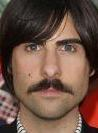

In [172]:
import random
img_path = glob.glob('./CELEBA/cropped_and_aligned/*')[random.randint(0,11639)]
Image.open(img_path)